<a href="https://colab.research.google.com/github/gkchandu/retail-sales-analytics-project/blob/main/02_Predictive_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Classification - Predicting Whether an Order Is Profitable

In [12]:
# Import core libraries for data handling, visualization, and ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# Load the cleaned Superstore dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Retail_Sales_Analytics_Project/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
# Create the target variable: 1 if the order made a profit, 0 if it resulted in a loss
df['Profitable'] = (df['Profit'] > 0).astype(int)

# Check how many orders are profitable vs not (class balance check)
df['Profitable'].value_counts()

,count
Profitable,
1,8058
0,1936


In [14]:
# Select the input features that will be used to predict profitability
features = ['Discount', 'Quantity', 'Category', 'Sub-Category', 'Region', 'Segment']

# Convert categorical (text) columns into numeric columns using one-hot encoding
X = pd.get_dummies(df[features], drop_first=True)

# Define the target variable
y = df['Profitable']

X.head()

,Discount,Quantity,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,Sub-Category_Copiers,...,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office
0,0.00,2,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.00,3,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,0.00,2,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
3,0.45,5,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,0.20,2,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [15]:
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures the split is reproducible every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm the shapes of the resulting train/test sets
print(X_train.shape, X_test.shape)

(7995, 25) (1999, 25)


In [28]:
# KNN is distance-based, so features need to be scaled to a similar range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Train a Logistic Regression model (simple baseline classifier)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
# Train a Decision Tree classifier (rule-based model)
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
# Train a Random Forest classifier (ensemble of many decision trees)
forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
# Import KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# Train KNN Classifier (using SCALED data, unlike the other 3 models)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [30]:
# Add KNN to the models dictionary
# Store all trained models in a dictionary for easy looping
models = {'Logistic Regression': log_model, 'Decision Tree': tree_model, 'Random Forest': forest_model}

# Loop through each model, predict on test data, and print its accuracy
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")

# KNN uses scaled test data for prediction, so we handle it separately
knn_preds = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_preds)
print(f"KNN Accuracy: {knn_acc:.4f}")

Logistic Regression Accuracy: 0.9420
Decision Tree Accuracy: 0.9300
Random Forest Accuracy: 0.9360
KNN Accuracy: 0.9375


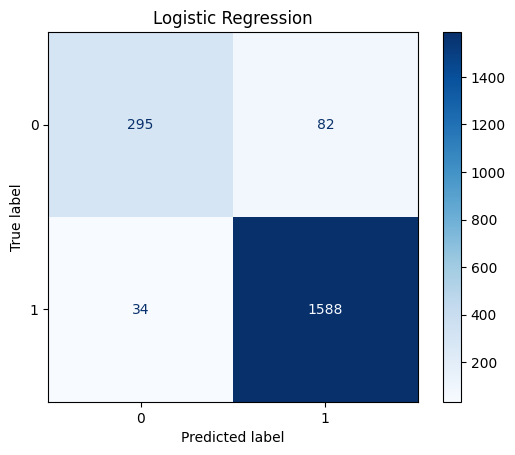

In [22]:
# Confusion matrix for Logistic Regression
preds = log_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Logistic Regression')
plt.show()

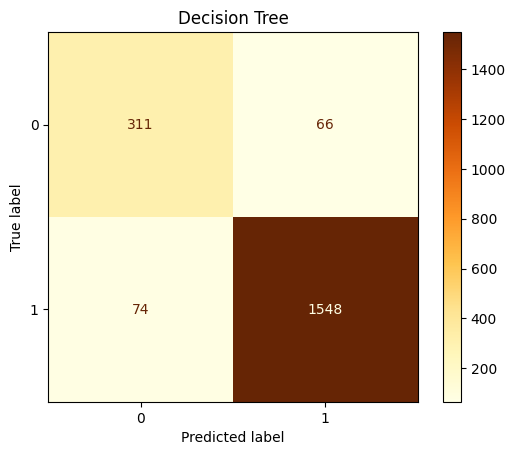

In [42]:
# Confusion matrix for Decision Tree
preds = tree_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot(cmap='YlOrBr')
plt.title('Decision Tree')
plt.show()

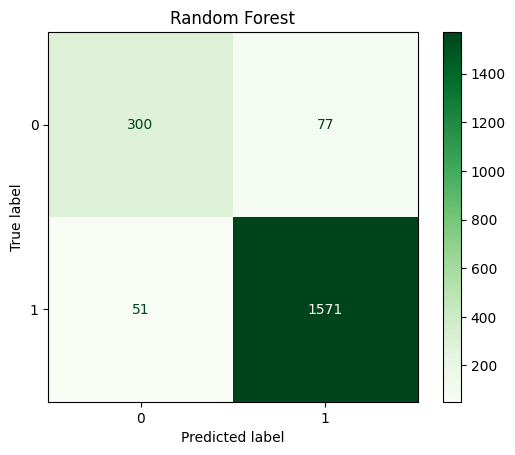

In [24]:
# Confusion matrix for Random Forest
preds = forest_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot(cmap='Greens')
plt.title('Random Forest')
plt.show()

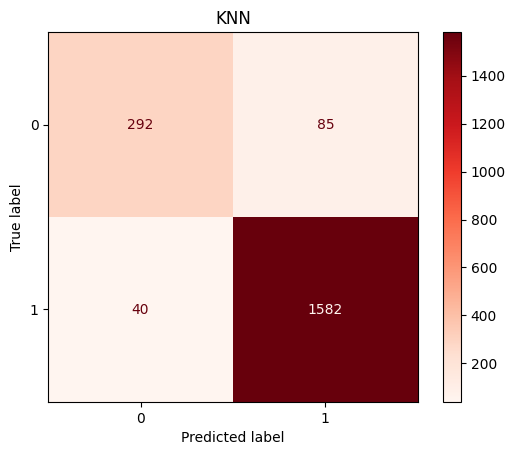

In [38]:
# Confusion matrix for KNN (using scaled test data)
knn_cm = confusion_matrix(y_test, knn_preds)
ConfusionMatrixDisplay(knn_cm).plot(cmap='Reds')
plt.title('KNN')
plt.show()

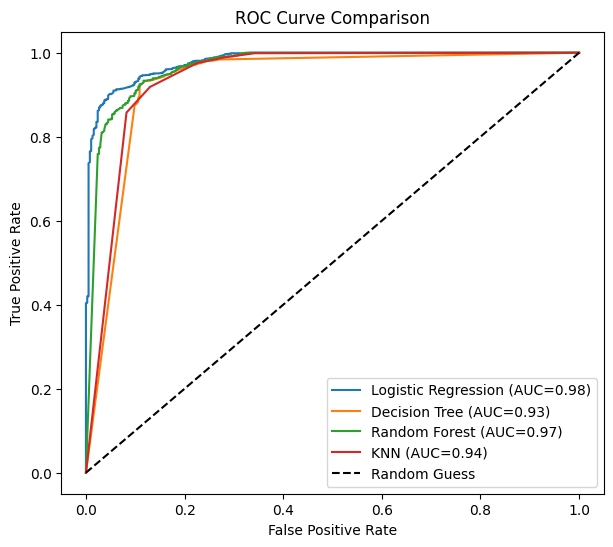

In [32]:
# Plot ROC curves for all 3 models on the same graph for comparison
plt.figure(figsize=(7,6))

for name, model in models.items():
    # Get predicted probabilities for the positive class (Profitable = 1)
    probs = model.predict_proba(X_test)[:,1]
    # Calculate the False Positive Rate and True Positive Rate at various thresholds
    fpr, tpr, _ = roc_curve(y_test, probs)
    # Calculate the Area Under the Curve (AUC) - higher is better
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")

# KNN - uses scaled test data
knn_probs = knn_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, knn_probs)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"KNN (AUC={auc_score:.2f})")

# Add a diagonal reference line representing random guessing
plt.plot([0,1],[0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Model Comparison & Conclusion

Overall, **Logistic Regression** performed best, achieving the highest accuracy
(**94.2%**) and AUC (**0.98**), meaning it most reliably distinguishes profitable
from non-profitable orders. **KNN** followed with **93.75%** accuracy and **0.94** AUC,
**Random Forest** scored **93.6%** accuracy with a strong **0.97** AUC, while
**Decision Tree** trailed slightly (**93.0%** accuracy, **0.93** AUC).

**Note on AUC:** AUC (Area Under the ROC Curve) measures how well a model separates
the two classes, on a scale from **0.5** (no better than random guessing) to **1.0**
(perfect separation). All four models scored above **0.9**, meaning all are strong,
with Logistic Regression having the clearest edge.

**Note on class imbalance:** the dataset is imbalanced — out of **9,994** total
orders, **8,058 (80.6%)** are profitable and only **1,936 (19.4%)** are not. This means
a model could reach roughly **80% accuracy** just by always predicting "Profitable,"
without learning anything meaningful. Because of this, **AUC is a more reliable metric**
here than accuracy alone.

**An interesting nuance:** while KNN slightly out-accuracies Random Forest (93.75% vs
93.6%), Random Forest's AUC (0.97) is noticeably higher than KNN's (0.94) — suggesting
Random Forest separates the two classes more reliably overall, even though KNN edges
ahead on this specific test split. **Decision Tree**, meanwhile, correctly identified
the most "Not Profitable" orders (**311 out of 377**), suggesting it may be more useful
if the business specifically wants to flag risky/unprofitable orders early, even at
the cost of overall accuracy.

**Recommendation:** Logistic Regression is the strongest general-purpose model for
this task, given its top accuracy and AUC despite the class imbalance. Random Forest
is a close, more robust alternative that may generalize better on new data due to
its ensemble nature. KNN performs competitively but requires feature scaling, adding
extra preprocessing complexity compared to the tree-based models.

## Task 2: Switching to Regression - Predicting an Amount Instead of a Category

The task above (Task 1) was a **classification problem** — predicting a Yes/No
outcome (whether an order is Profitable or not).

Task 2 below is a **regression problem** — instead of predicting a category, we're
now predicting an actual number: the **Sales amount** for an order. This requires
different models (**Linear Regression, Decision Tree, Random Forest, Gradient
Boosting, XGBoost, SVR, and KNN Regressors**) and different evaluation metrics
(**R² and RMSE** instead of accuracy, confusion matrix, or AUC), since we're no
longer measuring "correct vs incorrect" but rather "how close was the prediction
to the actual number."

In [44]:
# Install XGBoost - not pre-installed in Colab by default
!pip install xgboost -q

In [45]:
# Import regression models and evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [77]:
# Target variable: the actual Sales amount (a number, not Yes/No)
y_reg = df['Sales']

# Reuse the same encoded features from Task 1
X_reg = X.copy()

X_reg.head()

,Discount,Quantity,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,Sub-Category_Copiers,...,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office
0,0.00,2,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.00,3,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,0.00,2,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
3,0.45,5,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,0.20,2,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [78]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(X_train_r.shape, X_test_r.shape)

(7995, 25) (1999, 25)


In [79]:
# SVR and KNN are distance-based, so features need scaling
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

In [80]:
# Train Linear Regression (unscaled data)
lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)

LinearRegression()

In [81]:
# Train Decision Tree Regressor (unscaled data)
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_r, y_train_r)

DecisionTreeRegressor(random_state=42)

In [82]:
# Train Random Forest Regressor (unscaled data)
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_r, y_train_r)

RandomForestRegressor(random_state=42)

In [83]:
# Train Gradient Boosting Regressor (unscaled data)
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_r, y_train_r)

GradientBoostingRegressor(random_state=42)

In [84]:
# Train XGBoost Regressor (unscaled data)
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train_r, y_train_r)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
svr_reg = SVR()  # back to default, no tuning
svr_reg.fit(X_train_r_scaled, y_train_r)

SVR()

In [86]:
# Train KNN Regressor (SCALED data - required for this model)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r_scaled, y_train_r)

KNeighborsRegressor()

In [87]:
reg_models = {
    'Linear Regression': lin_model,
    'Decision Tree': tree_reg,
    'Random Forest': forest_reg,
    'Gradient Boosting': gb_reg,
    'XGBoost': xgb_reg
}

for name, model in reg_models.items():
    preds = model.predict(X_test_r)
    r2 = r2_score(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    print(f"{name}: R² = {r2:.4f}, RMSE = {rmse:.2f}")

svr_preds = svr_reg.predict(X_test_r_scaled)
print(f"SVR: R² = {r2_score(y_test_r, svr_preds):.4f}, RMSE = {np.sqrt(mean_squared_error(y_test_r, svr_preds)):.2f}")

knn_preds_r = knn_reg.predict(X_test_r_scaled)
print(f"KNN: R² = {r2_score(y_test_r, knn_preds_r):.4f}, RMSE = {np.sqrt(mean_squared_error(y_test_r, knn_preds_r)):.2f}")

Linear Regression: R² = 0.1863, RMSE = 693.28
Decision Tree: R² = 0.0920, RMSE = 732.36
Random Forest: R² = 0.1963, RMSE = 689.02
Gradient Boosting: R² = 0.2233, RMSE = 677.35
XGBoost: R² = 0.1717, RMSE = 699.48
SVR: R² = -0.0098, RMSE = 772.34
KNN: R² = 0.1049, RMSE = 727.16


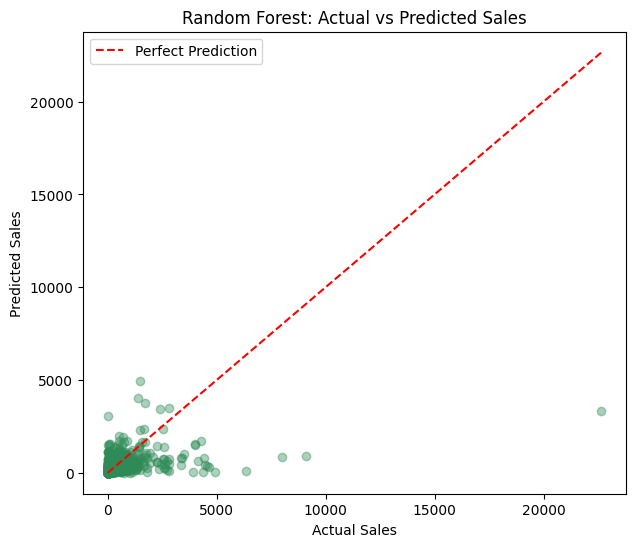

In [88]:
plt.figure(figsize=(7,6))
plt.scatter(y_test_r, forest_reg.predict(X_test_r), alpha=0.4, color='seagreen')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Random Forest: Actual vs Predicted Sales')
plt.legend()
plt.show()

## Task 2 Conclusion

Across all 7 models, **Gradient Boosting** performed best overall (**R² = 0.2233**,
**RMSE = 677.35**), followed closely by **Random Forest** (**R² = 0.1963**). Overall,
R² scores were modest across all models, suggesting Sales amount is difficult to
predict precisely from the available features alone (Discount, Quantity, Category,
Region, Segment) - likely because factors like exact product pricing aren't captured
in this feature set.

**Additional experiment:** I also tested applying a log-transform to the Sales target
(to address its skewed distribution) along with two extra features (Ship Mode, Order
Month). This improved **SVR** (R² from -0.0098 to 0.1204) and **KNN** (R² from 0.1049 to
0.1211) noticeably, but slightly reduced performance for the tree-based models
(Random Forest, Gradient Boosting, Decision Tree) and Linear Regression. This suggests
tree-based models were already handling Sales' skewed distribution reasonably well on
their own, while distance-based models (SVR, KNN) benefited more from the transform.

**Overall recommendation:** Gradient Boosting (original, untransformed) remains the
best single model for this task.

**Future improvement:** predicting Sales accurately would likely require additional
features not present in this dataset - such as unit price, historical demand, or
specific product-level pricing - rather than just order-level attributes like
Discount and Category.

## Why Both Tasks Together

**Task 1** answered a yes/no question — is this order profitable? But that alone
doesn't tell the business the **scale** of an order — a **50** dollars sale and a **5,000** dollars
sale could both be labeled "Profitable," yet they matter very differently to
the business.

**Task 2** predicts the actual Sales amount, which gives a more
complete picture: not just **whether** an order is good, but **how much** it's
worth. Together, both tasks are more useful than either alone — one tells you
the outcome, the other tells you the scale of that outcome.